In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import os
import gc
from pathlib import Path
from define_data_and_variables import opes_config, opes_hash, data, version
import json
from matplotlib.collections import LineCollection

In [2]:
base_dir = Path.cwd()
print(base_dir)

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
c14_label = r"$^{230}$Th" if "d18o" in data["dn"] else r"$^{14}$C"
measure = "mm" if "d18o" in data["dn"] else "cm"

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable_try_running
wah_d18o


In [3]:
base_dir = Path.cwd()
dir = base_dir / f"output/{data["dn"]}/{version}"
output_dir = dir / f"{opes_hash}"
print(output_dir)
hmc_config = opes_config["hmcc"]

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_OPES_normal_clean_d18o_stable_try_running\output\wah_d18o\0\82b34e8af4


In [4]:
color_list = plt.cm.viridis(np.linspace(0, 1, np.min((hmc_config["nch"], 5))))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

(20, 51)


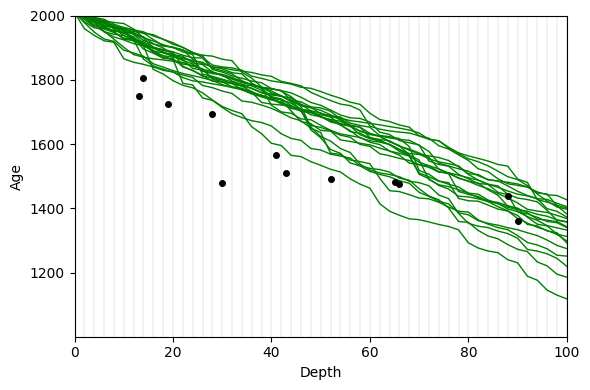

In [5]:

cumulative_sums = np.cumsum(hmc_config["sp"], axis=1) * data["dc"]
zeros = np.zeros((*hmc_config["sp"].shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(hmc_config["sp"])
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(np.min(data["d18ort"]), np.max(data["d18ort"]))
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{dir}/sp_age_depth.jpg")
plt.show()

In [6]:
base_dir = Path.cwd()
df = np.load(f"{output_dir}/df.npy", mmap_mode = "r")
print(df[:, -1, :])

[[   0.          -54.00571757  -99.22430371 -137.18921529 -169.2212936
  -196.39441435 -219.59656584 -239.56836602 -256.88013246 -272.02142902
  -285.44335656 -297.53736941 -308.62581322 -318.83786464 -328.23150207
  -337.03121795 -345.3574607  -353.22788175 -360.75139175 -367.98353922
  -374.91819818 -381.54711299 -387.97074138 -394.25140591 -400.28387633
  -405.94731033 -411.11063065 -415.69080003 -419.68536771 -423.14103642]
 [   0.          -54.00571654  -99.22427362 -137.18900291 -169.22083969
  -196.39405925 -219.59650736 -239.56864281 -256.88055552 -272.02165606
  -285.44340732 -297.5373745  -308.62581347 -318.83786465 -328.23150207
  -337.03121796 -345.3574607  -353.22788176 -360.75139176 -367.98353923
  -374.91819819 -381.547113   -387.97074138 -394.25140591 -400.28387633
  -405.94731033 -411.11063065 -415.69080004 -419.68536772 -423.14103642]
 [   0.          -54.00525736  -99.22360487 -137.18846516 -169.22040223
  -196.39364603 -219.59609709 -239.56823275 -256.88014548 -272.

C:\Users\hanna\AppData\Local\Temp\ipykernel_31284\4023452788.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


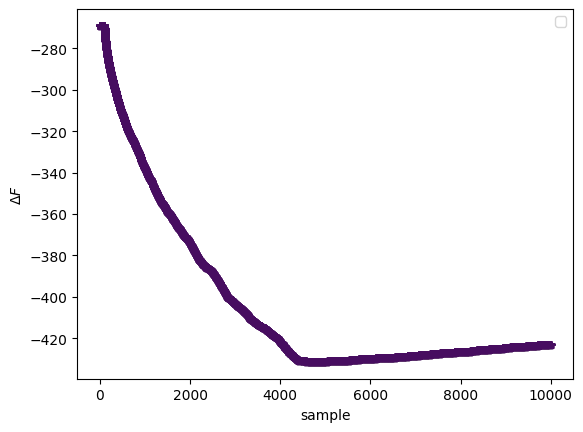

In [7]:
fig, ax = plt.subplots()
ind = -1
chain = 0
x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
sample_delta_F = np.squeeze(df[chain, :, ind])
ax.plot(x[:10000], sample_delta_F[:10000], '*-', color = temp_colors[1])
plt.legend()
plt.xlabel(f"sample")
plt.ylabel(r"$\Delta F$")
plt.savefig(f"{output_dir}/df_{ind}.jpg")
plt.show()


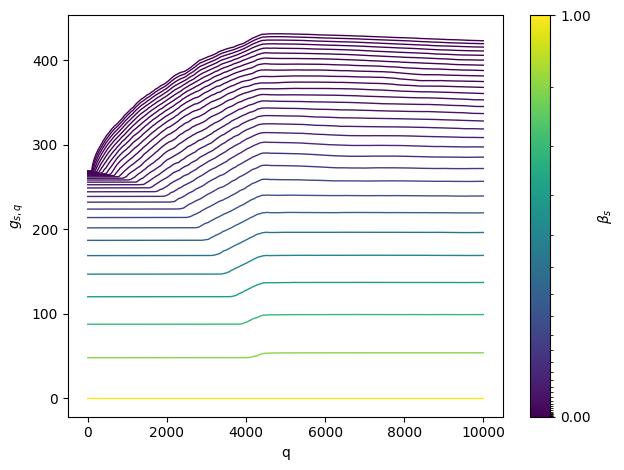

In [8]:
import matplotlib as mpl
fig, ax = plt.subplots()

norm = mpl.colors.Normalize(vmin=min(opes_config['bs']), vmax=max(opes_config['bs']))
cmap = plt.cm.viridis

for k in range(opes_config["nt"]):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:10000], -sample_delta_F[:10000], '-', linewidth = 1, color=cmap(norm(opes_config['bs'][k])), label = fr"$\beta_{{{k}}} = $" + f"{opes_config['bs'][k]:.2f}")

plt.xlabel(f"q")
plt.ylabel(r"$g_{s, q}$")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"$\beta_s$")
ticks = [min(opes_config["bs"]), max(opes_config["bs"])]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
cbar.ax.yaxis.set_minor_locator(
    plt.FixedLocator(opes_config["bs"])
)

plt.tight_layout()
plt.savefig(f"{output_dir}/gs.jpg")
plt.show()


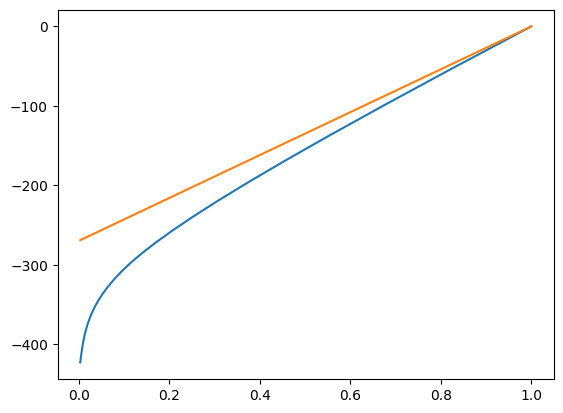

In [9]:
plt.figure()
plt.plot(opes_config["bs"], df[0, -1, :])
plt.plot(opes_config["bs"], 270 * (opes_config["bs"] - 1))
plt.show()

In [10]:
del df
gc.collect()

7341

In [11]:
cutout = 1000
bias_values = np.load(f"{output_dir}/bias.npy", mmap_mode='r')[:, cutout:]
energy_values = np.load(f"{output_dir}/energy.npy", mmap_mode='r')[:, cutout:]


In [12]:
neff = np.sum(np.exp(bias_values), axis = 1)**2 / np.sum(np.exp(bias_values)**2, axis = 1)
print(neff)

[8.40704139e+02 1.11658829e+03 1.25504163e+03 7.65063859e+02
 1.00000281e+00 6.94577057e+02 1.74138976e+00            nan
 1.06935252e+00 4.41473989e+02 1.13227836e+03 9.36377997e+02
 2.02736114e+00            nan 1.30417118e+00 1.23906667e+03
 8.60023930e+02 4.47289364e+02            nan 8.01797476e+02]


C:\Users\hanna\AppData\Local\Temp\ipykernel_31284\1155228474.py:1: RuntimeWarning: invalid value encountered in divide
  neff = np.sum(np.exp(bias_values), axis = 1)**2 / np.sum(np.exp(bias_values)**2, axis = 1)


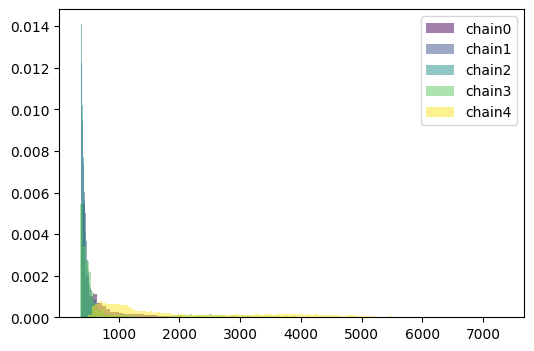

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(np.min((hmc_config["nch"], 5))):
    ax.hist(energy_values[i, cutout:], color = color_list[i], alpha = 0.5, label = f"chain{i}", bins = 100, density = True)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

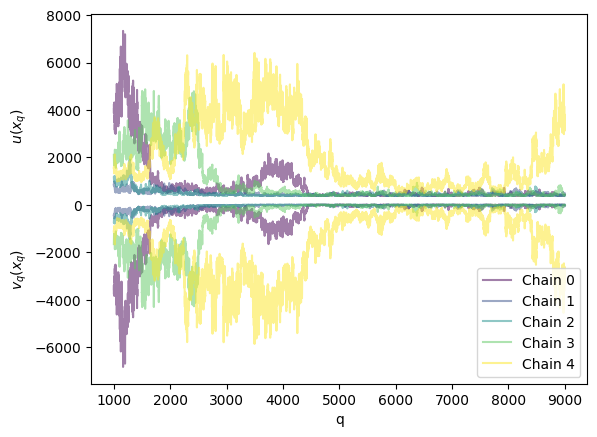

In [14]:
plt.figure()
el = 10000
for i in range(np.min((hmc_config["nch"], 5))):
    plt.plot(np.linspace(cutout, len(bias_values[0, :el]), len(bias_values[i, cutout:el])), bias_values[i, cutout:el], color = color_list[i], alpha = 0.5, label = f"Chain {i}")
    plt.plot(np.linspace(cutout, len(bias_values[0, :el]), len(bias_values[i, cutout:el])), energy_values[i, cutout:el], color = color_list[i], alpha = 0.5)
plt.xlabel("q")
plt.ylabel(r"$v_q(x_q)$                        $u(x_q)$")
plt.legend()
plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

In [15]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [16]:
print(az.summary(samples))

         mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
x[0]    9.296   6.095   4.076   22.809      0.786    1.303     173.0   
x[1]   15.046   5.909   2.114   19.088      0.620    0.596     124.0   
x[2]   22.748   8.437   2.035   30.013      1.116    0.877      97.0   
x[3]    8.510   6.817   0.779   20.181      0.609    1.207     757.0   
x[4]    6.210   6.071   0.610   14.432      0.406    0.926     578.0   
x[5]    9.057   9.234   0.945   23.598      0.927    1.832     195.0   
x[6]   30.181  11.257   2.047   40.310      1.426    1.942      89.0   
x[7]    8.833   4.875   0.906   18.639      0.262    0.445     410.0   
x[8]   15.209   6.271   1.642   24.901      0.488    0.562     189.0   
x[9]    6.967   3.239   1.444   12.865      0.158    0.237     439.0   
x[10]   8.533   3.635   2.101   12.711      0.484    0.090      66.0   
x[11]   3.007   2.941   0.414    7.930      0.348    0.408      52.0   
x[12]   3.098   3.616   0.488    7.697      0.410    0.676      

In [17]:
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(hmc_config["nch"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(hmc_config["nch"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(hmc_config["nch"])]
print(min_energies)

[np.float64(369.6819946385588), np.float64(371.33687537552464), np.float64(369.0869955545379), np.float64(366.7335477318038), np.float64(494.4062627339183), np.float64(370.5460813097501), np.float64(495.0613262586862), np.float64(1257.5047886523616), np.float64(461.2685610109673), np.float64(370.71076532786446), np.float64(370.3222109561331), np.float64(370.79080604316533), np.float64(454.8466061656029), np.float64(844.6929478784817), np.float64(472.41437193267404), np.float64(368.9342000380704), np.float64(370.7679310132822), np.float64(371.0092324824049), np.float64(1064.2637991573602), np.float64(370.1660361585961)]


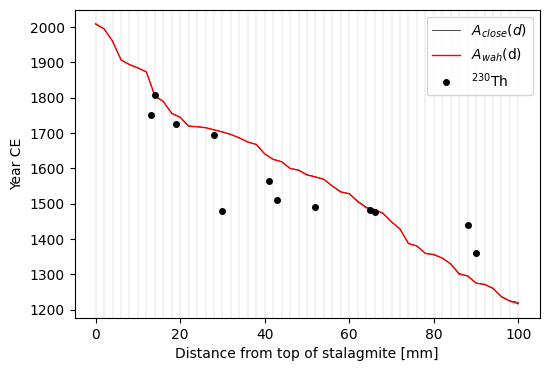

In [21]:
chain = 1
fig, ax = plt.subplots(figsize=(6, 4))
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
plt.show()



C:\Users\hanna\AppData\Local\Temp\ipykernel_31284\1556759067.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  ax.errorbar(


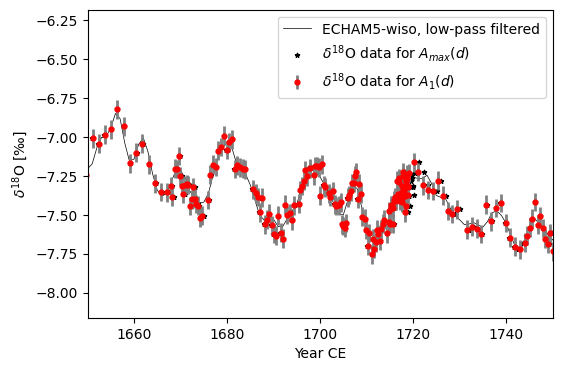

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
ax.errorbar(
    data["d18ota"], 
    data["d18o"], 
    yerr=data["d18os"],       # The error values (can be a constant or array)
    color="red", 
    ecolor = "grey",
    fmt = ".k", 
    markersize=7,                # Makes the stars smaller (default is 6)
    linestyle="None",            # Ensures no lines connect the points
    # capsize=2,                   # Optional: adds "caps" to the ends of error bars
    elinewidth=2,              # Optional: makes the error bar lines thinner
    label=r"$\delta^{18}$O data for $A_1(d)$"
)

# ax.scatter(
#     np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain])))), 
#     data["d18o"], 
#     # yerr=data["d18os"],       # The error values (can be a constant or array)
#     color="black", 
#     marker="*", 
#     s=10,                # Makes the stars smaller (default is 6)
#     # linestyle="None",            # Ensures no lines connect the points
#     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
#     # elinewidth=0.5,              # Optional: makes the error bar lines thinner
#     label=r"Data regenerated from $A_{close}(d)$"
# )

ax.scatter(
    np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), 
    data["d18o"], 
    # yerr=data["d18os"],       # The error values (can be a constant or array)
    color="black", 
    marker="*", 
    s=10,                # Makes the stars smaller (default is 6)
    # linestyle="None",            # Ensures no lines connect the points
    # capsize=2,                   # Optional: adds "caps" to the ends of error bars
    # elinewidth=0.5,              # Optional: makes the error bar lines thinner
    label=r"$\delta^{18}$O data for $A_{max}(d)$"
)
# ax.plot(np.interp(data["d18od"], data["cs"], true_ages), data["d18o"], color = "purple", linestyle = '--', label = "true data")
# ax.scatter(np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), data["d18o"], color = "red", marker = 'o', markersidth = 0.1, label = "most likely data")
plt.xlim((1650, 1750))
plt.ylabel("$\\delta^{18}$O [‰]")
plt.xlabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/data_compare.jpg")
plt.show()


In [ ]:
resampled_samples = []
print(np.shape(bias_values))
weights = np.exp(bias_values)
print(np.sum(weights, axis = 0)**2/np.sum(weights**2))
for i in range(hmc_config["nch"]):
    weights_i = weights[i, :] / sum(weights[i, :])

    indices = np.random.choice(
        np.arange(0, len(weights_i)),
        size=10000,
        replace=True,
        p=weights_i,
    )
    resampled_samples.append(samples[i, indices, :])
    print(f"Chain {i} done resampling")

resampled_samples = np.array(resampled_samples)

(20, 9000)
[0.         0.         0.         ... 0.0003161  0.00032349 0.00039577]
13159.3499638605
Chain 0 done resampling
16694.380276060903
Chain 1 done resampling
19152.12725190074
Chain 2 done resampling
11355.511025456393
Chain 3 done resampling
1.6832624310921358e-31
Chain 4 done resampling
10607.654380864169
Chain 5 done resampling
5.938799489426291e-31
Chain 6 done resampling
0.0


C:\Users\hanna\AppData\Local\Temp\ipykernel_31284\1986633102.py:7: RuntimeWarning: invalid value encountered in divide
  weights_i = weights[i, :] / sum(weights[i, :])


ValueError: probabilities contain NaN

In [ ]:
chain = 0
index = 12
interesting_depth = index * data["dc"]

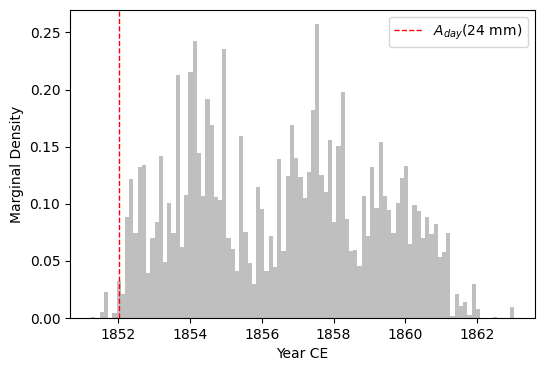

In [ ]:
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[chain][:, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density=True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} " + measure + ")")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

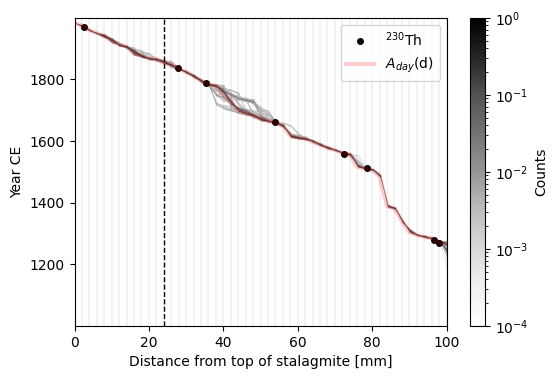

In [ ]:
from matplotlib import colors

X = resampled_samples[chain].T
D, N = X.shape

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

norm_age = age

# Time bins
dt = 1 if np.max(data["d18ort"]) - np.min(data["d18ort"]) < 2000 else 10
t_edges = np.arange(np.min(data["d18ort"]), np.max(data["d18ort"]) + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = data["H"] / 1000
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for j in range(Z):
    C[j, :], _ = np.histogram(A[j, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    linewidth = 0.1 if i != index else 1
    ax.axvline(x=c, color='k', linestyle='--', linewidth = linewidth)


ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = c14_label)
ax.plot(data["d18od"], data["d18ota"], color = "red", linewidth=3, alpha = 0.2, label = f"{data_name}(d)")

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Counts")
plt.xlabel("Distance from top of stalagmite [" + measure + "]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/ad_samples_chain_{chain}.jpg")
plt.show()